# K Means Clustering Implementation Example

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from rice_ml.Unsupervised_Learning.k_means_clustering import KMeans 

from rice_ml.processing.preprocessing import train_test_split, standardize
from rice_ml.processing.postprocessing import PostProcessor

from sklearn.datasets import make_blobs 

# Set the Seaborn theme
sns.set_theme()

# Set the Seaborn theme
sns.set_theme()

/Users/ccarr21/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Cluster Creation and Exploration

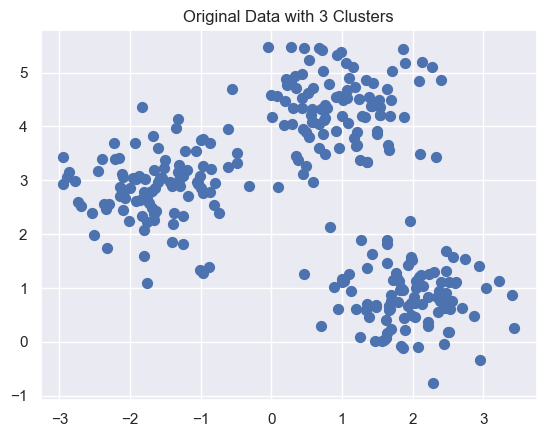

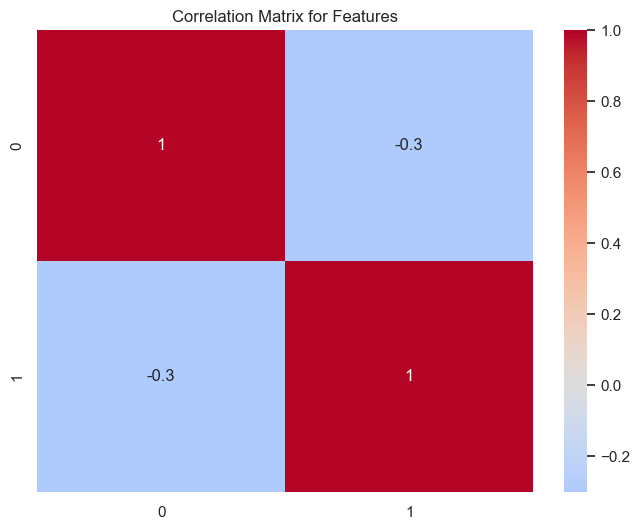

In [2]:
# Create 3 distinct clusters of data
X, y = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)

plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Original Data with 3 Clusters")
plt.show()

# Correlation Matrix for Features
plt.figure(figsize=(8, 6))
sns.heatmap(pd.DataFrame(X).corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix for Features")
plt.show()

# Preprocessing

In [5]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Verifying the shapes of the splits
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing labels shape: {y_test.shape}")
# Scaling the features
X_train, X_test = standardize(X_train, X_test)
# Instantiating and training the K Means Clustering Algorithm for Random and KMeans++
k_means_cluster = KMeans(n_clusters=3, random_state=42)
k_means_cluster.fit(X_train)
k_means_plus = KMeans(n_clusters=3, random_state=42, task = "kmeans++")
k_means_plus.fit(X_train)

print("KMeans Clusterer trained successfully.")
print(f"KMeans Clusterer inertia: {k_means_cluster.inertia_}")
print("KMeans++ trained successfully.")
print(f"KMeans++ inertia: {k_means_plus.inertia_}")

Training features shape: (240, 2)
Testing features shape: (60, 2)
Training labels shape: (240,)
Testing labels shape: (60,)


TypeError: KMeans.__init__() got an unexpected keyword argument 'task'

# Prediction and Evaluation

In [ ]:
processor = PostProcessor()
# Generate predictions on the test set for visualization
k_means_cluster_pred = k_means_cluster.predict(X_test)
k_means_plus_pred = k_means_plus.predict(X_test)

# Metrics for KMeans Random Clusterer
report = processor.classification_metrics(y_test, k_means_cluster_pred)
print(f"Classification Metrics: ", report)
# Accuracy of the KMeans Random Clusterer
accuracy = processor.accuracy(y_test, k_means_cluster_pred)
print(f"Accuracy: ", accuracy)

# Metrics for KMeans++ Clusterer
report = processor.classification_metrics(y_test, k_means_plus_pred)
print(f"Classification Metrics: ", report)
# Accuracy of the KMeans++ Clusterer
acc = processor.accuracy(y_test, k_means_plus_pred)
print(f"Accuracy: ", acc)


NameError: name 'k_means_plus' is not defined